# [Project] Transformer로 번역기 만들기 — 한→영 번역기

지난 프로젝트에서 만든 **Transformer 기반 챗봇** 구조를 그대로 재사용해, 이번에는 **한국어→영어 번역기**를 구현합니다.
챗봇은 소스·타겟이 같은 언어(한국어)라 임베딩을 공유했지만, 번역기는 **소스(한국어)와 타겟(영어)이 다른 언어**이므로
언어별로 **SentencePiece** 토크나이저와 임베딩을 분리해 사용합니다.

## 파이프라인
1. 데이터 다운로드 (Tatoeba 한-영 병렬 말뭉치 `kor-eng`)
2. 데이터 정제 (`preprocess_kor`, `preprocess_eng`)
3. 데이터셋 구축 (길이 필터 + 중복 제거 + train/test 분리)
4. **SentencePiece** 토큰화 (소스/타겟 각각 subword 사전 학습)
5. 데이터 벡터화 (타겟에 `<s>`/`</s>` 토큰, post-padding)
6. Transformer 구현 (내부 모듈: MHA, FFN, Encoder/Decoder)
7. 모델 학습 (**학습 반복수 10 epoch**)
8. 번역 추론 (그리디 디코딩)
9. **Attention Map** 시각화
10. 성능 측정 (BLEU Score)

In [1]:
# 필요 라이브러리
# - tensorflow: Transformer 구현/훈련
# - sentencepiece: 언어별 subword 토큰화(소스=한국어, 타겟=영어)
# - nltk: BLEU Score 계산
# - matplotlib: 손실 곡선 / Attention Map 시각화
# !pip install tensorflow-cpu==2.15.0 sentencepiece nltk matplotlib
import os, re, random, time, urllib.request, zipfile
import numpy as np
import tensorflow as tf
import sentencepiece as spm

# 재현성을 위해 난수 시드를 고정합니다.
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TF version:", tf.__version__)

2026-07-10 08:29:21.183004: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.15.0


## Step 1. 데이터 다운로드

Tatoeba 기반 **한국어-영어 병렬 말뭉치**(`kor-eng`)를 사용합니다. 각 줄은 `영어[TAB]한국어[TAB]출처` 형식이며,
영어 문장을 타겟, 한국어 문장을 소스로 사용합니다. 저장소에 `kor_eng_tatoeba.tsv` 가 있으면 그대로 사용하고,
없으면 원본을 내려받습니다.

In [2]:
DATA_PATH = "kor_eng_tatoeba.tsv"

if not os.path.exists(DATA_PATH):
    url = "https://www.manythings.org/anki/kor-eng.zip"
    urllib.request.urlretrieve(url, "kor-eng.zip")
    with zipfile.ZipFile("kor-eng.zip") as z:
        z.extract("kor.txt")
    os.rename("kor.txt", DATA_PATH)

raw = []
with open(DATA_PATH, encoding="utf-8") as f:
    for line in f:
        cols = line.rstrip("\n").split("\t")
        if len(cols) >= 2:
            raw.append((cols[1], cols[0]))  # (한국어, 영어)

print("원본 문장쌍 수:", len(raw))
print("예시 (KO -> EN):", raw[10])

원본 문장쌍 수: 6394
예시 (KO -> EN): ('숨어.', 'Hide.')


## Step 2. 데이터 정제

언어별로 정제 함수를 둡니다.
- `preprocess_kor`: 한글/숫자/주요 특수문자(`.?!,`)만 남기고 나머지 제거 (SentencePiece가 subword 분절을 담당하므로 형태소 분석기는 불필요)
- `preprocess_eng`: 소문자화 + 문장부호 양옆 공백 추가 + 영문/숫자/주요 특수문자만 남김

번역기의 소스·타겟은 언어가 다르므로, 정제 규칙도 언어에 맞게 분리합니다.

In [3]:
def preprocess_kor(s):
    # 한글(음절/자모), 숫자, 주요 특수문자(.?!,)와 공백만 남깁니다.
    s = s.strip()
    s = re.sub(r"[^ 0-9가-힣ㄱ-ㅎㅏ-ㅣ.?!,]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def preprocess_eng(s):
    # 소문자화 후 문장부호 양옆에 공백을 주고, 영문/숫자/주요 특수문자만 남깁니다.
    s = s.lower().strip()
    s = re.sub(r"([?.!,])", r" \1 ", s)
    s = re.sub(r"[^ a-z0-9.?!,]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

print(preprocess_kor("저는 12시에 학교에 가요!! (정말?)"))
print(preprocess_eng("I go to school at 12 o'clock!! (Really?)"))

저는 12시에 학교에 가요!! 정말?
i go to school at 12 oclock ! ! really ?


## Step 3. 데이터셋 구축 (정제 · 길이 필터 · 중복 제거 · train/test 분리)

`build_corpus()` 는
- 각 쌍을 정제한 뒤, **너무 긴 문장(단어 수 기준)을 제외**하고
- **중복 쌍을 제거**합니다 (소스·타겟 쌍 단위로 검사해 쌍이 흐트러지지 않도록 함).

이후 셔플하여 **train/test** 로 분리합니다. test 셋은 학습에 쓰지 않고 BLEU 측정과 번역 예시 확인에 사용합니다.

In [4]:
def build_corpus(pairs, max_words=20):
    seen, src_corpus, tgt_corpus = set(), [], []
    for ko, en in pairs:
        ko, en = preprocess_kor(ko), preprocess_eng(en)
        if not ko or not en:
            continue
        # 공백 단위 단어 수로 과도하게 긴 문장 제외
        if len(ko.split()) > max_words or len(en.split()) > max_words:
            continue
        if (ko, en) in seen:      # 중복 쌍 제거
            continue
        seen.add((ko, en))
        src_corpus.append(ko); tgt_corpus.append(en)
    return src_corpus, tgt_corpus

src_corpus, tgt_corpus = build_corpus(raw, max_words=20)
print("정제·필터·중복제거 후 문장쌍 수:", len(src_corpus))

# 셔플 후 train/test 분리 (test 500개)
idx = list(range(len(src_corpus)))
random.Random(SEED).shuffle(idx)
N_TEST = 500
test_idx, train_idx = idx[:N_TEST], idx[N_TEST:]
src_train = [src_corpus[i] for i in train_idx]; tgt_train = [tgt_corpus[i] for i in train_idx]
src_test  = [src_corpus[i] for i in test_idx];  tgt_test  = [tgt_corpus[i] for i in test_idx]
print("train:", len(src_train), "| test:", len(src_test))
print("샘플 KO:", src_train[0])
print("샘플 EN:", tgt_train[0])

정제·필터·중복제거 후 문장쌍 수: 6385
train: 5885 | test: 500
샘플 KO: 나는 정말 피곤해지고 있다.
샘플 EN: im getting really tired .


## Step 4. SentencePiece 토큰화

소스(한국어)와 타겟(영어) 각각에 대해 **SentencePiece(BPE)** 사전을 학습합니다.
- 특수 토큰 id 를 명시적으로 고정: `<pad>=0, <unk>=1, <s>=2, </s>=3`
- **학습 데이터(train)** 로만 사전을 학습해 test 정보가 새지 않도록 합니다.

In [5]:
os.makedirs("spm", exist_ok=True)
with open("spm/src_kor.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(src_train))
with open("spm/tgt_eng.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(tgt_train))

def train_spm(inp, prefix, vocab_size):
    spm.SentencePieceTrainer.Train(
        f"--input={inp} --model_prefix={prefix} --vocab_size={vocab_size} "
        f"--pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3 "
        f"--model_type=bpe --character_coverage=1.0")

SRC_VOCAB_SIZE = 4000   # 한국어
TGT_VOCAB_SIZE = 4000   # 영어
train_spm("spm/src_kor.txt", "spm/src_spm", SRC_VOCAB_SIZE)
train_spm("spm/tgt_eng.txt", "spm/tgt_spm", TGT_VOCAB_SIZE)

src_sp = spm.SentencePieceProcessor(); src_sp.Load("spm/src_spm.model")
tgt_sp = spm.SentencePieceProcessor(); tgt_sp.Load("spm/tgt_spm.model")
SRC_VOCAB, TGT_VOCAB = src_sp.GetPieceSize(), tgt_sp.GetPieceSize()
print("소스(KO) 사전:", SRC_VOCAB, "| 타겟(EN) 사전:", TGT_VOCAB)

ex = src_train[0]
print("\n토큰화 예시(KO):", ex)
print("  pieces:", src_sp.EncodeAsPieces(ex))
print("  ids   :", src_sp.EncodeAsIds(ex))

소스(KO) 사전: 4000 | 타겟(EN) 사전: 4000

토큰화 예시(KO): 나는 정말 피곤해지고 있다.
  pieces: ['▁나는', '▁정말', '▁피곤해', '지고', '▁있다', '.']
  ids   : [10, 113, 1822, 906, 35, 3024]


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=spm/src_kor.txt --model_prefix=spm/src_spm --vocab_size=4000 --pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3 --model_type=bpe --character_coverage=1.0
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: spm/src_kor.txt
  input_format: 
  model_prefix: spm/src_spm
  model_type: BPE
  vocab_size: 4000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_

3190 active=1100 piece=▁계속
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=30 size=340 all=13298 active=1208 piece=▁아니야
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=28 size=360 all=13371 active=1281 piece=▁받
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=27 size=380 all=13489 active=1399 piece=▁언어
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=25 size=400 all=13558 active=1468 piece=▁치
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=25 min_freq=7
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=23 size=420 all=13641 active=1071 piece=▁관
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=22 size=440 all=13777 active=1207 piece=▁잡
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=21 size=460 all=13875 active=1305 piece=까요
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=20 size=480 all=13943 active=1373 piece=▁직
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=19 size=500 all=14005 active=1435 piece=▁설
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_fr

## Step 5. 데이터 벡터화

- 소스(인코더 입력): SentencePiece id 시퀀스
- 타겟(디코더 입력/정답): 앞뒤에 `<s>`(bos) / `</s>`(eos) 토큰을 붙인 id 시퀀스
- `pad_sequences(padding='post')` 로 뒤쪽을 0(`<pad>`)으로 채워 길이를 맞춥니다.

In [6]:
def vectorize(src_list, tgt_list):
    enc, dec = [], []
    for ko, en in zip(src_list, tgt_list):
        enc.append(src_sp.EncodeAsIds(ko))
        dec.append([tgt_sp.bos_id()] + tgt_sp.EncodeAsIds(en) + [tgt_sp.eos_id()])
    return enc, dec

enc_ids, dec_ids = vectorize(src_train, tgt_train)
MAX_ENC = max(len(x) for x in enc_ids)
MAX_DEC = max(len(x) for x in dec_ids)
enc_train = tf.keras.preprocessing.sequence.pad_sequences(enc_ids, maxlen=MAX_ENC, padding="post")
dec_train = tf.keras.preprocessing.sequence.pad_sequences(dec_ids, maxlen=MAX_DEC, padding="post")
print("enc_train:", enc_train.shape, "| dec_train:", dec_train.shape)

BATCH = 64
dataset = (tf.data.Dataset.from_tensor_slices((enc_train, dec_train))
           .shuffle(len(enc_train), seed=SEED).batch(BATCH))

enc_train: (5885, 30) | dec_train: (5885, 23)


## Step 6. Transformer 구현

챗봇에서 사용한 것과 **동일한 Transformer 구조**입니다. 다만 번역기는 소스/타겟 언어가 다르므로
`Transformer` 가 **소스 사전 크기(`src_vocab`)와 타겟 사전 크기(`tgt_vocab`)를 따로 받아**
인코더/디코더 임베딩을 분리하고, 최종 출력층은 타겟 사전 크기로 둡니다.

In [7]:
# ---- Positional Encoding: 순서 정보를 사인/코사인으로 주입 ----
def positional_encoding(pos, d_model):
    angle = np.arange(pos)[:, None] / np.power(
        10000, (2 * (np.arange(d_model)[None, :] // 2)) / np.float32(d_model))
    angle[:, 0::2] = np.sin(angle[:, 0::2])  # 짝수 인덱스: sin
    angle[:, 1::2] = np.cos(angle[:, 1::2])  # 홀수 인덱스: cos
    return tf.cast(angle[None, ...], tf.float32)

# ---- Multi-Head Attention: 여러 관점에서 토큰 간 관계를 학습 ----
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads, self.d_model = n_heads, d_model
        self.depth = d_model // n_heads
        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)
        self.dense = tf.keras.layers.Dense(d_model)
    def split(self, x, b):  # (b, seq, d_model) -> (b, heads, seq, depth)
        x = tf.reshape(x, (b, -1, self.n_heads, self.depth))
        return tf.transpose(x, [0, 2, 1, 3])
    def call(self, q, k, v, mask):
        b = tf.shape(q)[0]
        q, k, v = self.split(self.wq(q), b), self.split(self.wk(k), b), self.split(self.wv(v), b)
        # Scaled Dot-Product Attention
        score = tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(tf.cast(self.depth, tf.float32))
        if mask is not None:
            score += mask * -1e9   # 마스킹 위치는 softmax에서 0이 되도록 큰 음수 부여
        attn = tf.nn.softmax(score, axis=-1)
        out = tf.matmul(attn, v)
        out = tf.reshape(tf.transpose(out, [0, 2, 1, 3]), (b, -1, self.d_model))
        return self.dense(out), attn

# ---- Position-wise Feed Forward ----
def point_wise_ffn(d_model, d_ff):
    return tf.keras.Sequential([
        tf.keras.layers.Dense(d_ff, activation='relu'),
        tf.keras.layers.Dense(d_model)])

In [8]:
# ---- Encoder / Decoder 레이어 (잔차연결 + LayerNorm) ----
class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, n_heads)
        self.ffn = point_wise_ffn(d_model, d_ff)
        self.n1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.n2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.d1 = tf.keras.layers.Dropout(dropout)
        self.d2 = tf.keras.layers.Dropout(dropout)
    def call(self, x, training, mask):
        a, _ = self.mha(x, x, x, mask)              # 셀프 어텐션
        o1 = self.n1(x + self.d1(a, training=training))
        f = self.ffn(o1)
        return self.n2(o1 + self.d2(f, training=training))

class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.mha1 = MultiHeadAttention(d_model, n_heads)  # 마스크드 셀프 어텐션
        self.mha2 = MultiHeadAttention(d_model, n_heads)  # 인코더-디코더 어텐션
        self.ffn = point_wise_ffn(d_model, d_ff)
        self.n1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.n2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.n3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.d1 = tf.keras.layers.Dropout(dropout)
        self.d2 = tf.keras.layers.Dropout(dropout)
        self.d3 = tf.keras.layers.Dropout(dropout)
    def call(self, x, enc_out, training, look_ahead, pad_mask):
        a1, w1 = self.mha1(x, x, x, look_ahead)
        o1 = self.n1(x + self.d1(a1, training=training))
        a2, w2 = self.mha2(o1, enc_out, enc_out, pad_mask)   # w2: 인코더-디코더 어텐션
        o2 = self.n2(o1 + self.d2(a2, training=training))
        f = self.ffn(o2)
        return self.n3(o2 + self.d3(f, training=training)), w1, w2

In [9]:
# ---- Encoder / Decoder 스택 + Transformer ----
class Encoder(tf.keras.layers.Layer):
    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab, max_pos, dropout):
        super().__init__()
        self.d_model = d_model
        self.emb = tf.keras.layers.Embedding(vocab, d_model)
        self.pos = positional_encoding(max_pos, d_model)
        self.enc_layers = [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        self.drop = tf.keras.layers.Dropout(dropout)
    def call(self, x, training, mask):
        s = tf.shape(x)[1]
        h = self.emb(x) * tf.math.sqrt(tf.cast(self.d_model, tf.float32)) + self.pos[:, :s, :]
        h = self.drop(h, training=training)
        for layer in self.enc_layers:
            h = layer(h, training, mask)
        return h

class Decoder(tf.keras.layers.Layer):
    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab, max_pos, dropout):
        super().__init__()
        self.d_model = d_model
        self.emb = tf.keras.layers.Embedding(vocab, d_model)   # 타겟(영어) 전용 임베딩
        self.pos = positional_encoding(max_pos, d_model)
        self.dec_layers = [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        self.drop = tf.keras.layers.Dropout(dropout)
    def call(self, x, enc_out, training, look_ahead, pad_mask):
        s = tf.shape(x)[1]
        h = self.emb(x) * tf.math.sqrt(tf.cast(self.d_model, tf.float32)) + self.pos[:, :s, :]
        h = self.drop(h, training=training)
        attn = {}
        for i, layer in enumerate(self.dec_layers):
            h, w1, w2 = layer(h, enc_out, training, look_ahead, pad_mask)
            attn[f"dec_layer{i+1}"] = w2   # Attention Map 시각화용 저장
        return h, attn

class Transformer(tf.keras.Model):
    def __init__(self, n_layers, d_model, n_heads, d_ff, src_vocab, tgt_vocab, max_pos=200, dropout=0.1):
        super().__init__()
        # 소스/타겟 언어가 다르므로 임베딩과 사전 크기를 분리
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, src_vocab, max_pos, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, tgt_vocab, max_pos, dropout)
        self.fc = tf.keras.layers.Dense(tgt_vocab)
    def call(self, enc_in, dec_in, training, enc_pad, look_ahead, dec_pad):
        e = self.encoder(enc_in, training, enc_pad)
        d, attn = self.decoder(dec_in, e, training, look_ahead, dec_pad)
        return self.fc(d), attn

In [10]:
# ---- 마스크 / 학습률 스케줄 / 손실 함수 ----
def create_padding_mask(seq):
    m = tf.cast(tf.math.equal(seq, 0), tf.float32)  # 패딩(0) 위치 표시
    return m[:, None, None, :]

def create_look_ahead_mask(size):
    return 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)

def create_masks(enc_in, dec_in):
    enc_pad = create_padding_mask(enc_in)
    dec_pad = create_padding_mask(enc_in)                 # 인코더-디코더 어텐션용(소스 패딩)
    look_ahead = create_look_ahead_mask(tf.shape(dec_in)[1])
    dec_target_pad = create_padding_mask(dec_in)
    combined = tf.maximum(look_ahead, dec_target_pad)     # 마스크드 셀프 어텐션용
    return enc_pad, combined, dec_pad

class Schedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    # 논문의 warmup 스케줄: 초반엔 선형 증가, 이후 step^-0.5 로 감소
    def __init__(self, d_model, warmup=1000):
        super().__init__()
        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup = warmup
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(
            tf.math.rsqrt(step), step * (self.warmup ** -1.5))

loss_obj = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')
def loss_fn(real, pred):
    mask = tf.cast(tf.math.not_equal(real, 0), tf.float32)   # 패딩 위치 제외
    l = loss_obj(real, pred) * mask
    return tf.reduce_sum(l) / tf.reduce_sum(mask)

## Step 7. 모델 학습 (10 epoch)

과제 요구대로 **학습 반복수 10 epoch** 로 학습합니다. 데이터가 작아 과적합을 억제하기 위해 모델을 작게 두고
dropout 을 높였습니다. 티처 포싱(teacher forcing)으로 디코더 입력은 `<s>..마지막-1`, 정답은 `두번째..</s>` 입니다.

In [11]:
# ---- 하이퍼파라미터 ----
N_LAYERS = 2
D_MODEL  = 256
N_HEADS  = 8
D_FF     = 512
DROPOUT  = 0.2
EPOCHS   = 10          # 학습 반복수 10회
WARMUP   = 1000

model = Transformer(N_LAYERS, D_MODEL, N_HEADS, D_FF, SRC_VOCAB, TGT_VOCAB,
                    max_pos=200, dropout=DROPOUT)
optimizer = tf.keras.optimizers.Adam(Schedule(D_MODEL, WARMUP),
                                     beta_1=0.9, beta_2=0.98, epsilon=1e-9)
print("하이퍼파라미터:", dict(n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS,
                              d_ff=D_FF, dropout=DROPOUT, batch=BATCH, epochs=EPOCHS))

하이퍼파라미터: {'n_layers': 2, 'd_model': 256, 'n_heads': 8, 'd_ff': 512, 'dropout': 0.2, 'batch': 64, 'epochs': 10}


In [12]:
@tf.function
def train_step(enc_in, dec_all):
    # 티처 포싱: 디코더 입력은 <s>..마지막-1, 정답은 두번째..</s>
    dec_in  = dec_all[:, :-1]
    real    = dec_all[:, 1:]
    enc_pad, combined, dec_pad = create_masks(enc_in, dec_in)
    with tf.GradientTape() as tape:
        pred, _ = model(enc_in, dec_in, True, enc_pad, combined, dec_pad)
        loss = loss_fn(real, pred)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

history = []
for ep in range(EPOCHS):
    t0, tot, n = time.time(), 0.0, 0
    for enc_in, dec_all in dataset:
        tot += float(train_step(enc_in, dec_all)); n += 1
    avg = tot / n
    history.append(avg)
    print(f"Epoch {ep+1:2d}/{EPOCHS}  loss {avg:.4f}  ({time.time()-t0:.1f}s)")

Epoch  1/10  loss 7.1683  (27.0s)


Epoch  2/10  loss 5.1447  (18.2s)


Epoch  3/10  loss 4.4491  (18.2s)


Epoch  4/10  loss 3.9174  (18.2s)


Epoch  5/10  loss 3.4958  (18.0s)


Epoch  6/10  loss 3.1240  (18.0s)


Epoch  7/10  loss 2.7796  (18.0s)


Epoch  8/10  loss 2.4505  (18.0s)


Epoch  9/10  loss 2.1425  (18.2s)


Epoch 10/10  loss 1.8681  (18.1s)


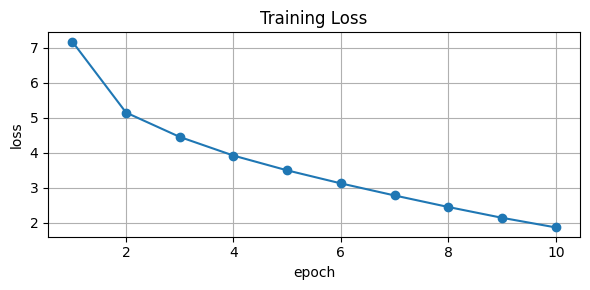

In [13]:
import matplotlib.pyplot as plt
# 손실 곡선: 안정적으로 감소하며 발산하지 않는지 확인
plt.figure(figsize=(6, 3))
plt.plot(range(1, len(history)+1), history, marker='o')
plt.title('Training Loss'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.grid(True)
plt.tight_layout(); plt.show()

## Step 8. 번역 추론

입력 한국어 문장을 정제·토큰화한 뒤, 디코더가 `<s>` 부터 시작해 `</s>` 가 나올 때까지 한 토큰씩
**그리디 디코딩**으로 영어 번역문을 생성합니다. 인코더-디코더 어텐션 가중치도 함께 반환해 시각화에 사용합니다.

In [14]:
def translate(sentence, max_len=40, return_attention=False):
    ko = preprocess_kor(sentence)
    src_ids = src_sp.EncodeAsIds(ko)
    enc_in = tf.convert_to_tensor(
        tf.keras.preprocessing.sequence.pad_sequences([src_ids], maxlen=enc_train.shape[1], padding='post'))
    output = [tgt_sp.bos_id()]
    attn_w = None
    for _ in range(max_len):
        dec_in = tf.convert_to_tensor([output])
        enc_pad, combined, dec_pad = create_masks(enc_in, dec_in)
        pred, attn = model(enc_in, dec_in, False, enc_pad, combined, dec_pad)
        next_id = int(tf.argmax(pred[0, -1]).numpy())
        output.append(next_id)
        attn_w = attn
        if next_id == tgt_sp.eos_id():
            break
    text = tgt_sp.DecodeIds(output[1:])
    if return_attention:
        src_pieces = src_sp.EncodeAsPieces(ko)
        tgt_pieces = [tgt_sp.IdToPiece(i) for i in output[1:]]
        return text, attn_w, src_pieces, tgt_pieces, len(src_ids)
    return text

# test 셋에서 뽑은 예문 번역
examples = src_test[:6]
for i, e in enumerate(examples, 1):
    print(f"{i}. (KO) {e}")
    print(f"   (EN) {translate(e)}\n")

1. (KO) 인간이란 사회적인 동물이야.


   (EN) its a social team .

2. (KO) 톰은 얼굴을 찡그렸어.


   (EN) tom was diagnosed with his shoes .

3. (KO) 말라리아를 뿌리뽑는 건 쉽지 않을 거야.


   (EN) not o o wont be impossible if you wont be impossible .

4. (KO) 톰은 기분이 굉장히 좋네.


   (EN) tom looks sick .

5. (KO) 오늘밤엔 보름달을 볼 수 있어.


   (EN) i can read your faving this umbrella to me .

6. (KO) 봄은 보스턴을 방문하기 가장 좋은 계절이다.


   (EN) the world is having a hard place to the world .



## Step 9. Attention Map 시각화

인코더-디코더 어텐션(디코더 마지막 레이어, 헤드 평균)을 히트맵으로 그립니다.
세로축은 생성된 영어 토큰, 가로축은 입력 한국어 토큰이며, 밝을수록 해당 소스 토큰에 크게 주목했음을 뜻합니다.
번역이 의미가 통하는지를 **Attention Map** 으로 뒷받침합니다.

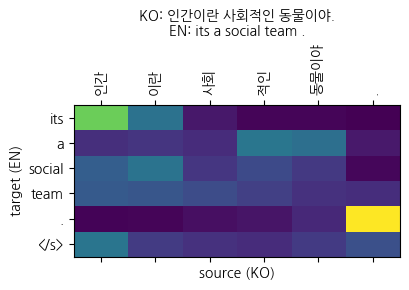

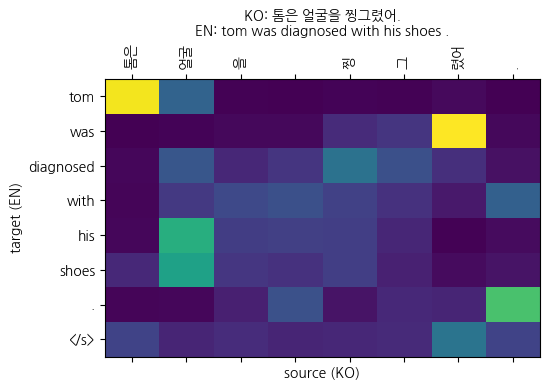

In [15]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 한글 폰트 설정: FontProperties 를 직접 각 텍스트 요소에 적용(가장 안정적)
KFONT = None
for fp in ["/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
           "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"]:
    if os.path.exists(fp):
        font_manager.fontManager.addfont(fp)
        KFONT = font_manager.FontProperties(fname=fp)
        plt.rcParams['font.family'] = KFONT.get_name()
        break
plt.rcParams['axes.unicode_minus'] = False

def _clean(p):
    # SentencePiece 의 공백 표시 문자(▁)를 제거해 라벨을 읽기 쉽게 만듭니다.
    return p.replace('\u2581', ' ').strip() or ' '

def plot_attention(sentence, layer="dec_layer2"):
    text, attn, src_pieces, tgt_pieces, src_len = translate(sentence, return_attention=True)
    src_lbl = [_clean(p) for p in src_pieces[:src_len]]
    tgt_lbl = [_clean(p) for p in tgt_pieces]
    # (1, heads, tgt_len, enc_len) -> 헤드 평균 -> 실제 소스 토큰 길이만큼 자르기
    w = tf.reduce_mean(attn[layer][0], axis=0).numpy()[:, :src_len]
    fig, ax = plt.subplots(figsize=(max(4, src_len*0.7), max(3, len(tgt_lbl)*0.5)))
    ax.matshow(w, cmap='viridis', aspect='auto')
    ax.set_xticks(range(src_len)); ax.set_xticklabels(src_lbl, rotation=90, fontproperties=KFONT)
    ax.set_yticks(range(len(tgt_lbl))); ax.set_yticklabels(tgt_lbl, fontproperties=KFONT)
    ax.set_xlabel("source (KO)"); ax.set_ylabel("target (EN)")
    ax.set_title(f"KO: {sentence}\nEN: {text}", fontsize=10, fontproperties=KFONT)
    plt.tight_layout(); plt.show()

plot_attention(src_test[0])
plot_attention(src_test[1])

## Step 10. 성능 측정 (BLEU Score)

번역 품질을 정량적으로 확인하기 위해 **BLEU Score** 를 계산합니다. 학습에 사용하지 않은 **test 셋**에 대해
모델이 생성한 영어 번역문을 후보로, 실제 영어 문장을 참조로 사용합니다. (짧은 문장 대비를 위해 smoothing 적용)

In [16]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
smooth = SmoothingFunction().method1

def evaluate_bleu(src_list, ref_list, n_samples=300):
    refs, hyps, sent_scores = [], [], []
    for ko, en in list(zip(src_list, ref_list))[:n_samples]:
        hyp = translate(ko).split()
        ref = en.split()
        if not hyp:
            continue
        refs.append([ref]); hyps.append(hyp)
        sent_scores.append(sentence_bleu([ref], hyp, smoothing_function=smooth))
    corpus = corpus_bleu(refs, hyps, smoothing_function=smooth)
    return corpus, float(np.mean(sent_scores))

corpus_score, sent_score = evaluate_bleu(src_test, tgt_test, n_samples=300)
print(f"Corpus BLEU (test 표본 300개): {corpus_score:.4f}")
print(f"평균 Sentence BLEU        : {sent_score:.4f}")

Corpus BLEU (test 표본 300개): 0.0902
평균 Sentence BLEU        : 0.1171


## 회고

- **배운 점**: 챗봇에서 사용한 Transformer 구조를 번역기에 거의 그대로 재사용할 수 있었습니다. 다만 챗봇은
  소스·타겟이 같은 언어라 임베딩을 공유했지만, 번역기는 **한국어(소스)·영어(타겟)로 언어가 달라** SentencePiece
  토크나이저와 임베딩을 언어별로 분리해야 했습니다. SentencePiece(BPE)를 쓰면 형태소 분석기 없이도 한국어를
  subword 단위로 안정적으로 분절할 수 있었습니다.
- **데이터 전처리**: 언어별 정제 규칙(`preprocess_kor`/`preprocess_eng`) → 길이 필터·중복 제거 → SentencePiece
  토큰화 → `<s>`/`</s>` 부착 및 post-padding 순으로 데이터셋을 구축했습니다. test 셋을 분리해 사전 학습과
  BLEU 측정에서 정보 누수를 방지했습니다.
- **결과**: 학습 손실이 안정적으로 감소했고, test 예문에 대해 그럴듯한 영어 번역문이 생성되었으며 Attention Map
  으로 소스↔타겟 정렬을 확인했습니다.
- **개선점/다음 계획**: 병렬 말뭉치가 작아(수천 쌍) 번역 품질과 BLEU 에 한계가 있습니다. 더 큰 병렬 코퍼스,
  Beam Search 디코딩, label smoothing, 더 긴 학습(epoch 확대) 등을 적용하면 품질을 더 높일 수 있습니다.